In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import json

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
})

In [2]:
def plot(json_file, x_lim_in_sec, y_lim=None, startup_end=0):
    # y_lim = None
    # read json file
    with open(json_file) as f:
        j = json.load(f)

        jits = j['jits']
        end = j['end'] / 1000
        jit_duration = j['jit_duration'] / 1000
        exec_duration = j['exec_duration'] / 1000

        if y_lim is None:
            y_lim = len(jits)

        print(f'Waiting: {jit_duration:.2f}')
        print(f'Execution: {exec_duration:.2f}')
        print(f'Total: {end:.2f}')

    # figure
    fig, ax = plt.subplots(figsize=(8, 2), dpi=320)

    # jits timeline
    waiting_color = 'crimson'
    hit_color = 'darkgreen'
    for idx, record in enumerate(jits):
        color = waiting_color
        start = record[0]
        finish = record[1]
        duration = finish - start
        if abs(duration) <= 2:  # check hit
            color = hit_color
        ax.barh(idx, duration, left=start, color=color, edgecolor=color, linewidth=1)

    # times texts
    fontsize = 15
    ax.text((end - 8) * 1000,
            40,
            "Total: {:.1f}s".format(end),
            color='navy',
            fontsize=fontsize,
            horizontalalignment='center',
            verticalalignment='center')
    ax.text((end - 8) * 1000,
            120,
            "Waiting: {:.1f}s".format(jit_duration),
            color='crimson',
            fontsize=fontsize,
            horizontalalignment='center',
            verticalalignment='center')

    # draw an arrow from 0 to startup_end <->
    arrow_y = y_lim - 50
    if startup_end > 6:
        ax.annotate("", xy=(startup_end * 1000, arrow_y), xytext=(0, arrow_y),
                    arrowprops=dict(arrowstyle='<|-|>,head_width=.25,head_length=.25', color='crimson', lw=1))
    if startup_end > 6:
        ax.text((startup_end / 2) * 1000,
                arrow_y,
                "Startup",
                color='crimson',
                fontsize=fontsize,
                horizontalalignment='center',
                verticalalignment='center',
                bbox=dict(boxstyle='square,pad=.01', fc='white', ec='none'),
                rotation=0)
    else:
        ax.text((startup_end / 2) * 1000,
                arrow_y - 95,
                "Startup",
                color='crimson',
                fontsize=fontsize,
                horizontalalignment='center',
                verticalalignment='center',
                bbox=None,
                rotation=70)
    # draw a dashed vertical line at startup_end
    ax.axvline(x=startup_end * 1000, color='crimson', linestyle='dashed', lw=1, alpha=0.35)

    # draw an arrow from startup_end to end <->
    ax.annotate("", xy=(end * 1000, arrow_y), xytext=(startup_end * 1000, arrow_y),
                arrowprops=dict(arrowstyle='<|-|>,head_width=.25,head_length=.25', color='navy', lw=1))
    ax.text(((end + startup_end) / 2) * 1000,
            arrow_y,
            "Execution",
            color='navy',
            fontsize=fontsize,
            horizontalalignment='center',
            verticalalignment='center',
            bbox=dict(boxstyle='square,pad=.01', fc='white', ec='none'))
    ax.axvline(x=(end + .2) * 1000, color='navy', linestyle='solid', lw=1, alpha=0.35)

    # x limit
    xlim = x_lim_in_sec * 1000
    ax.set_xlim(0, xlim)
    # x ticks every 1000ms (1s)
    xstep = 5000
    ax.set_xticks(np.arange(0, xlim + 1, xstep))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x / 1000)) if xstep > 1 else None)
    # set x labels fontsize 15
    ax.tick_params(axis='both', labelsize=fontsize)

    # mark finish time on x-axis as "finished" xtick
    # ax.set_xticks([end * 1000], minor=True)
    # ax.set_xticklabels(["Finished"], minor=True, fontsize=5, color='purple', rotation=90, verticalalignment='top', horizontalalignment='center')
    # ax.tick_params(axis='x', which='minor', length=5)

    # remove top spine
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)

    ax.set_ylim(-25, y_lim)
    # y ticks every 25
    ystep = 100
    ax.set_yticks(np.arange(0, y_lim + 1, ystep))
    # make size smaller
    ax.set_yticklabels(np.arange(0, y_lim + 1, ystep))

    # margin
    ax.margins(0.0)

    # grid
    # ax.grid(which='major', linestyle='--', linewidth=0.5, zorder=-100)

    # labels
    ax.set_ylabel('Functions', fontsize=15, labelpad=0)
    # ax.xaxis.set_label_text('Time (s)')

    # layout
    plt.tight_layout()

    # save to file
    input_file = json_file.split('/')[-1]
    file_name_without_extension = input_file[:-len('.json')]
    output_file = f"out/{file_name_without_extension}.pdf"
    fig.savefig(output_file, bbox_inches='tight', transparent="True", pad_inches=0, dpi=320, format='pdf')

    # show
    plt.show()

Waiting: 21.36
Execution: 51.19
Total: 72.55


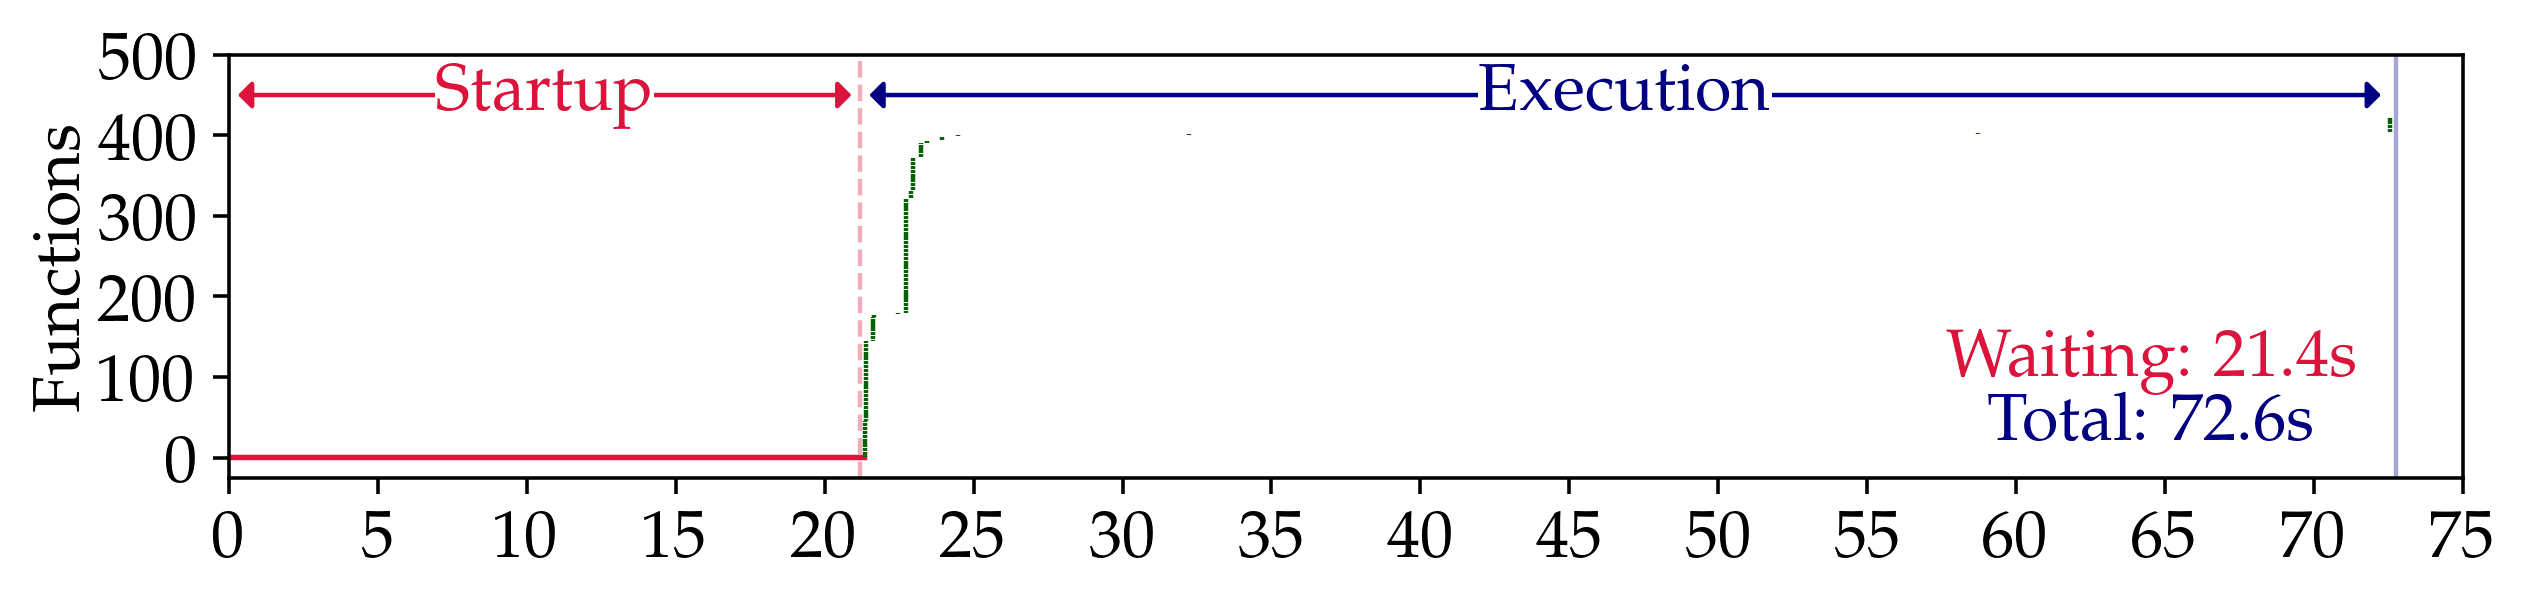

In [3]:
plot('in/x264.local.aot.json', x_lim_in_sec=75, y_lim=500, startup_end=21.2)

Waiting: 16.40
Execution: 51.67
Total: 68.08


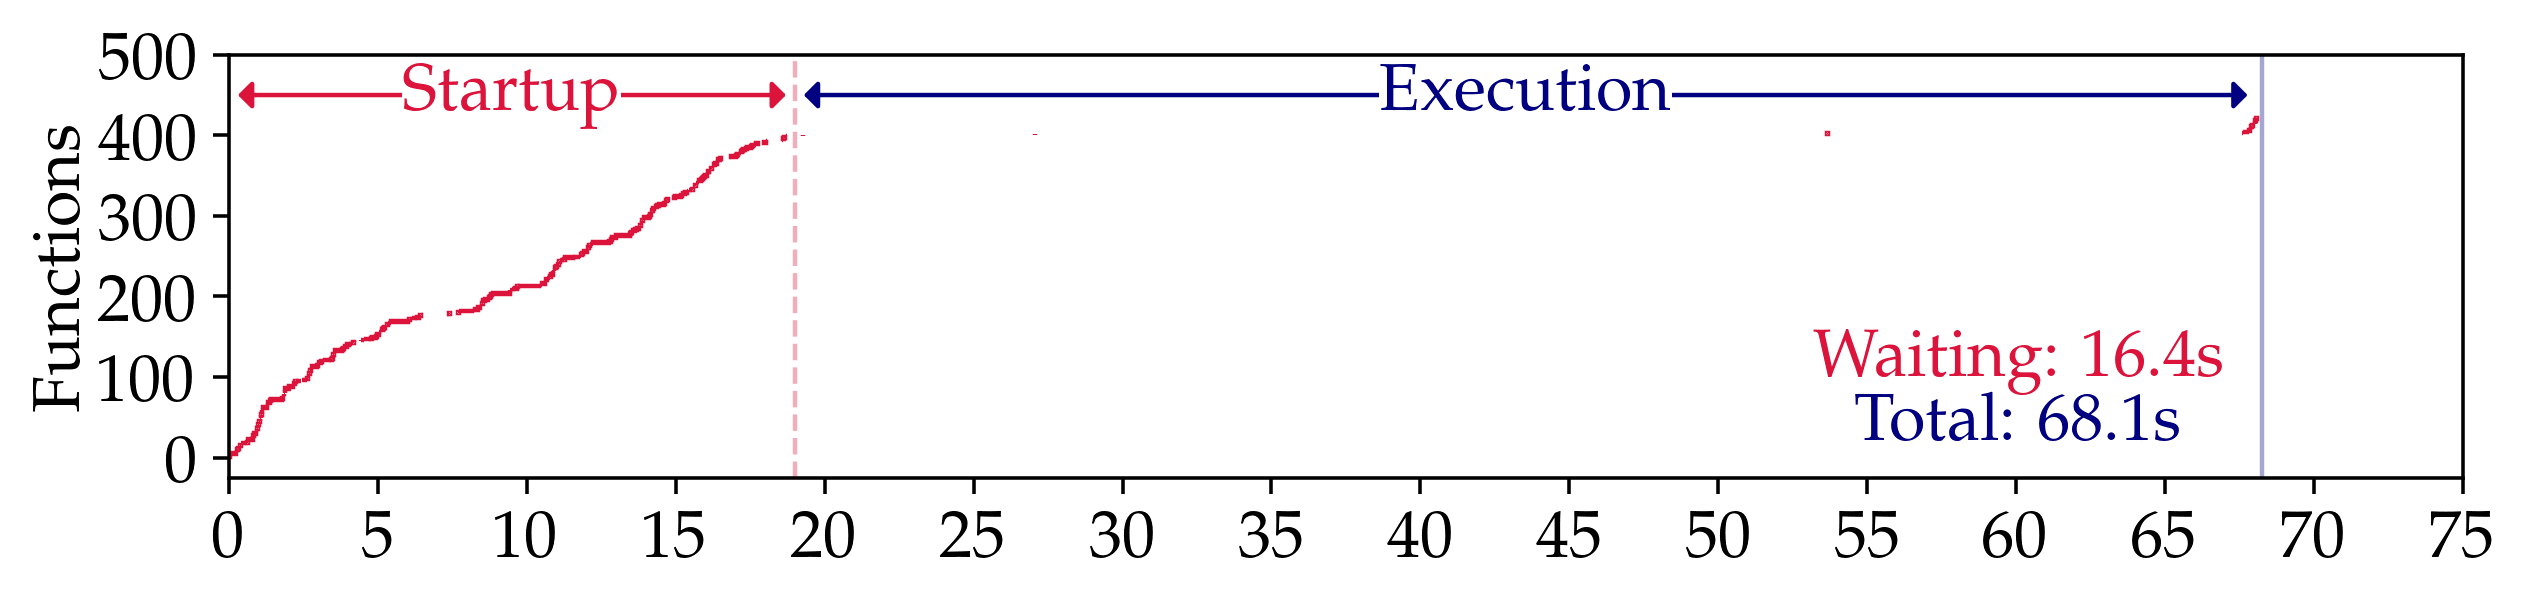

In [4]:
plot('in/x264.local.jit.json', x_lim_in_sec=75, y_lim=500, startup_end=19)

Waiting: 20.27
Execution: 52.38
Total: 72.66


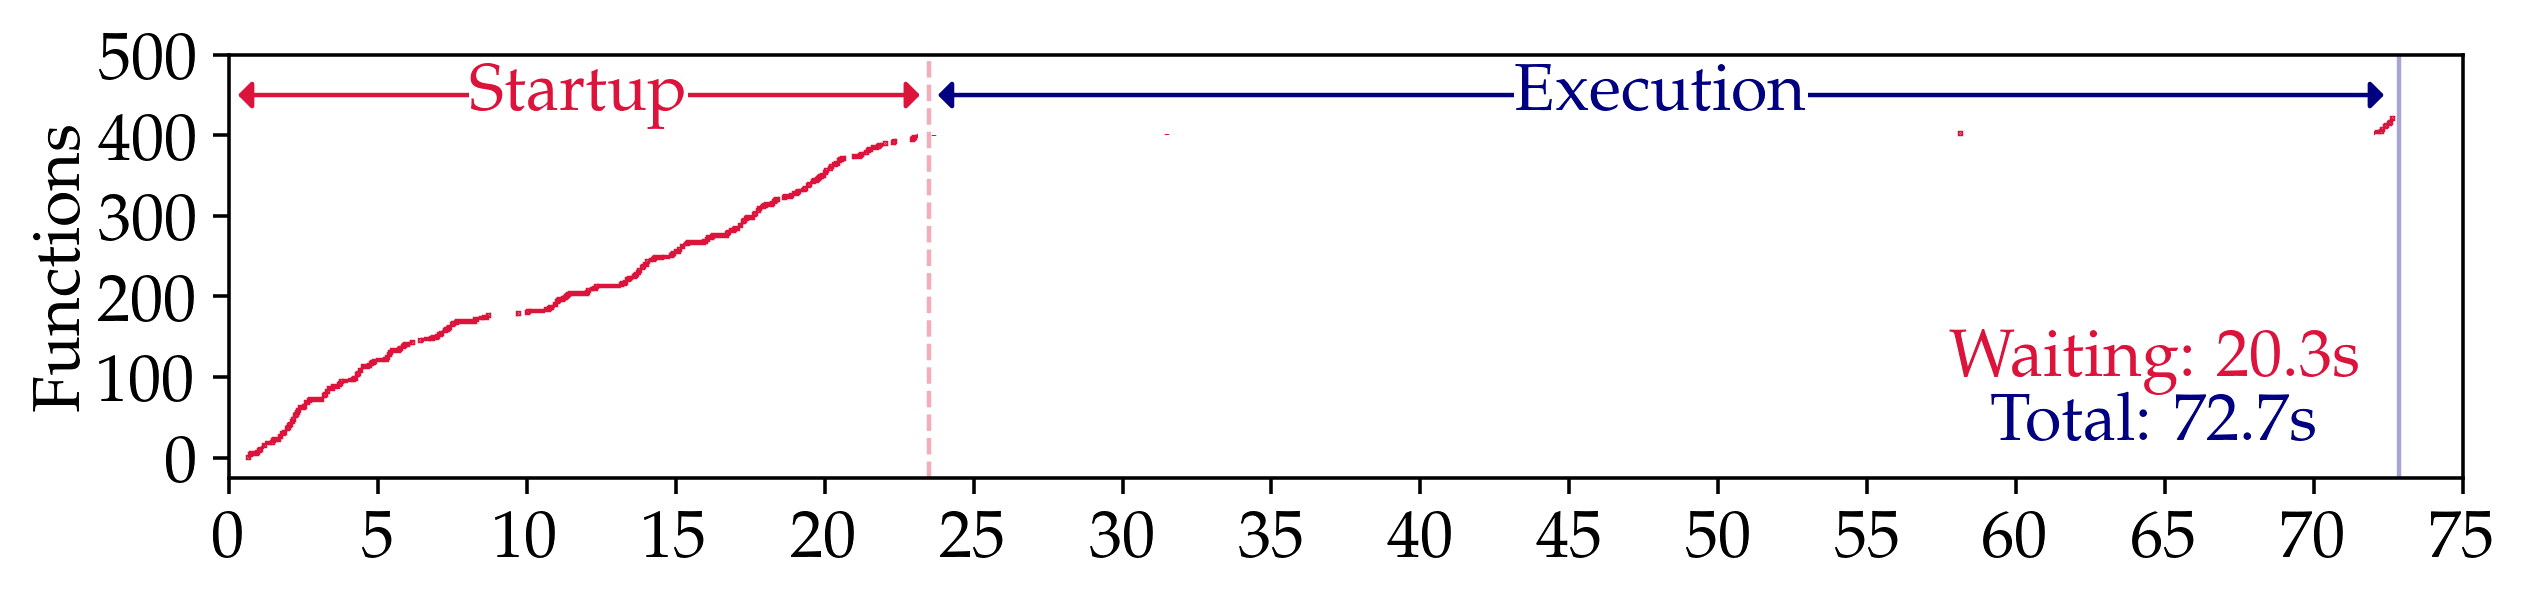

In [5]:
plot('in/x264.remote.jit.json', x_lim_in_sec=75, y_lim=500, startup_end=23.5)

Waiting: 2.47
Execution: 51.47
Total: 53.94


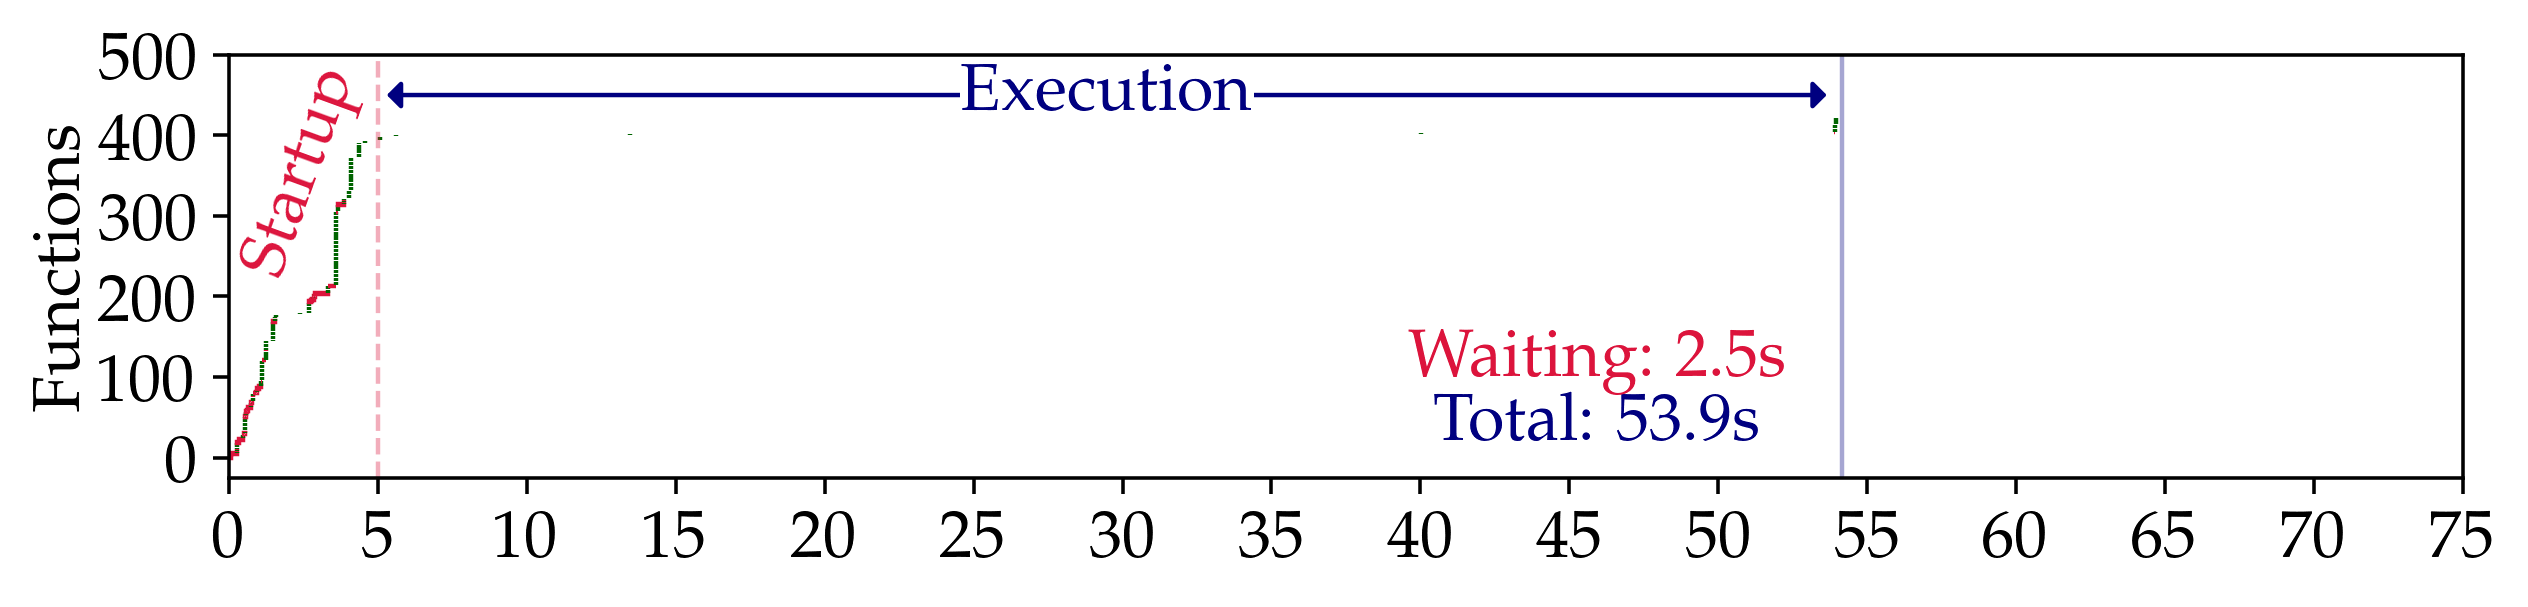

In [6]:
plot('in/x264.remote.speculative.json', x_lim_in_sec=75, y_lim=500, startup_end=5)

In [45]:
def plot(json_file):
    with open(json_file) as f:
        lines = f.readlines()
        jsons = [json.loads(line) for line in lines]

    max_end = max([j['end'] for j in jsons])

    for j in jsons:
        jits = j['jits']
        end = j['end'] / 1000
        jit_duration = j['jit_duration'] / 1000
        exec_duration = j['exec_duration'] / 1000

        print(f'Waiting: {jit_duration:.2f}')
        print(f'Execution: {exec_duration:.2f}')
        print(f'Total: {end:.2f}')

        # figure
        fig, ax = plt.subplots(figsize=(8, 2), dpi=320)
        ax.set_xlim(0, max_end)

        # jits timeline
        waiting_color = 'crimson'
        hit_color = 'darkgreen'
        for idx, record in enumerate(jits):
            color = waiting_color
            start = record[0]
            finish = record[1]
            duration = finish - start
            if abs(duration) <= 2:  # check hit
                color = hit_color
            ax.barh(idx, duration, left=start, color=color, edgecolor=color, linewidth=.5)
            
        # times texts
        fontsize = 9
        ax.text((max_end - 1500),
                80,
                "Total: {:.1f}s".format(end),
                color='navy',
                fontsize=fontsize,
                horizontalalignment='center',
                verticalalignment='center')
        ax.text((max_end - 1500),
                120,
                "Waiting: {:.1f}s".format(jit_duration),
                color='crimson',
                fontsize=fontsize,
                horizontalalignment='center',
                verticalalignment='center')
        
        
        plt.show()

Waiting: 21.27
Execution: 2.40
Total: 23.67


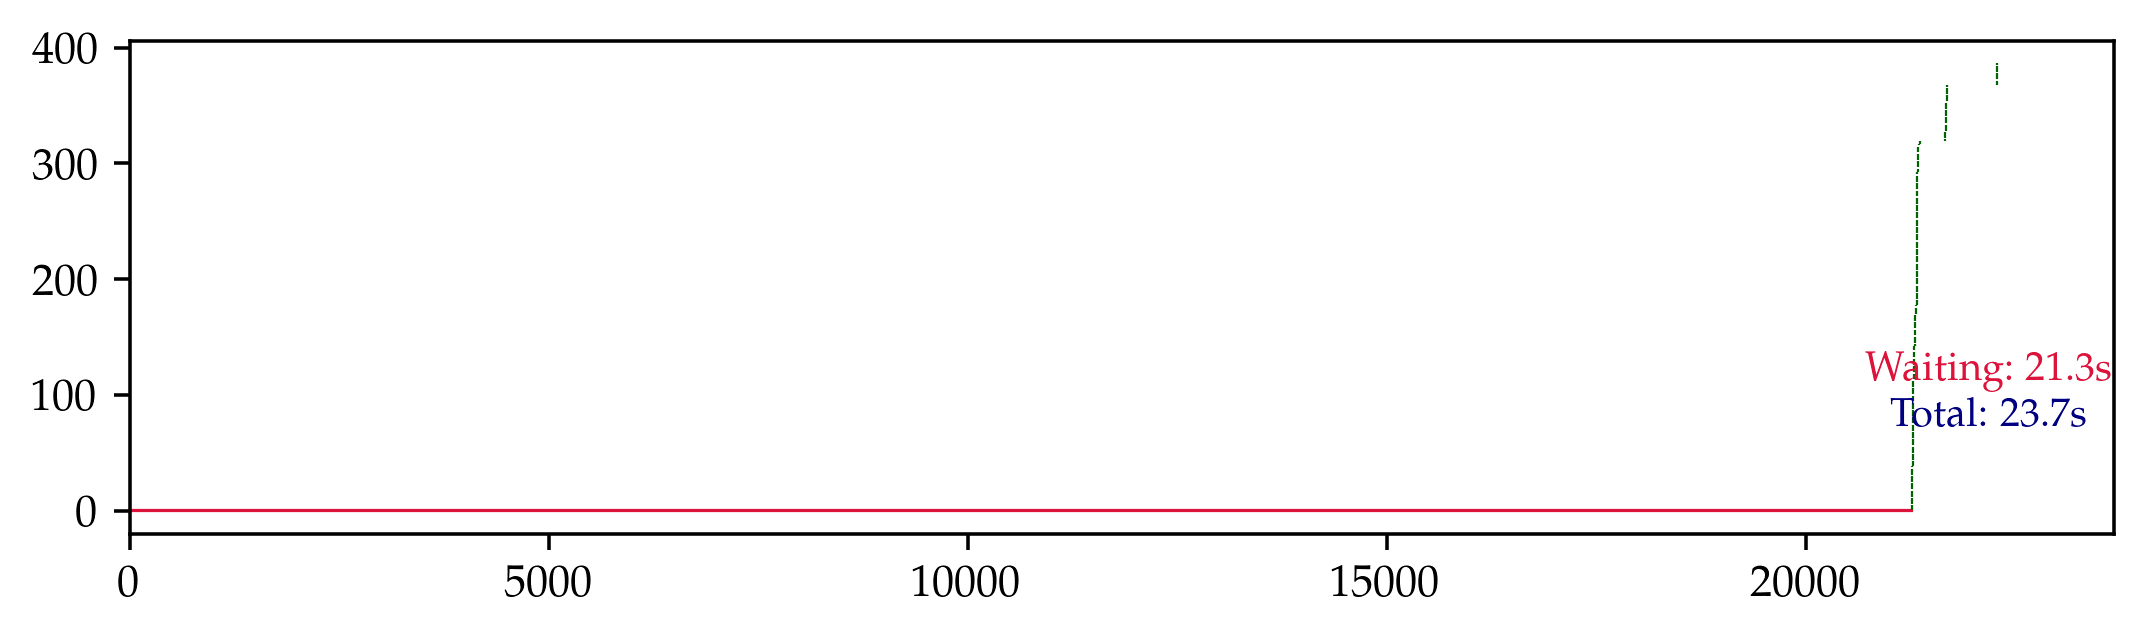

Waiting: 1.32
Execution: 3.01
Total: 4.33


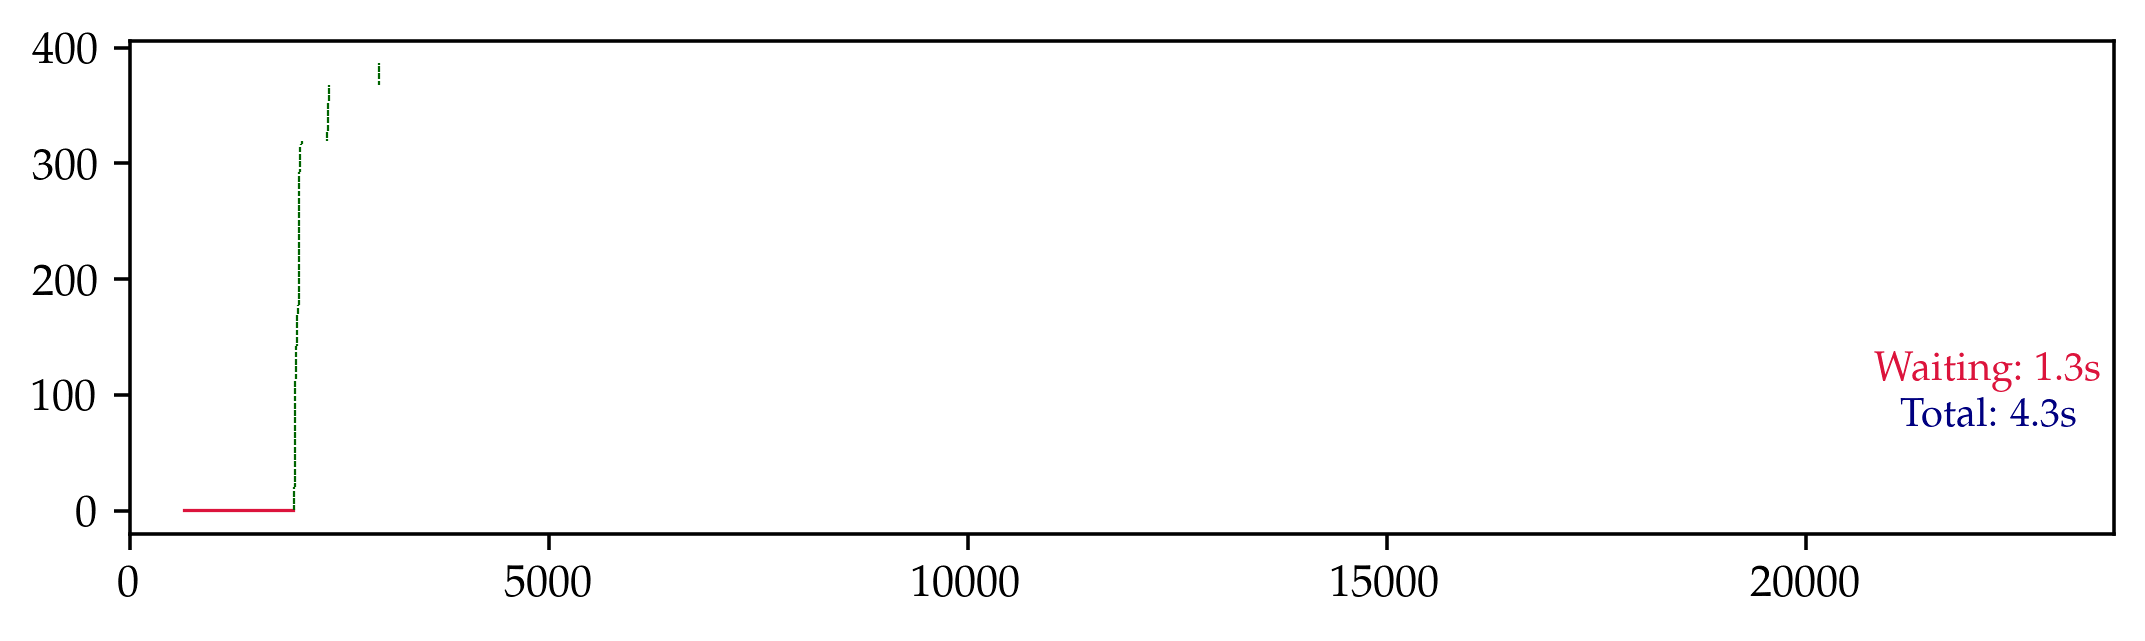

Waiting: 11.78
Execution: 3.22
Total: 15.00


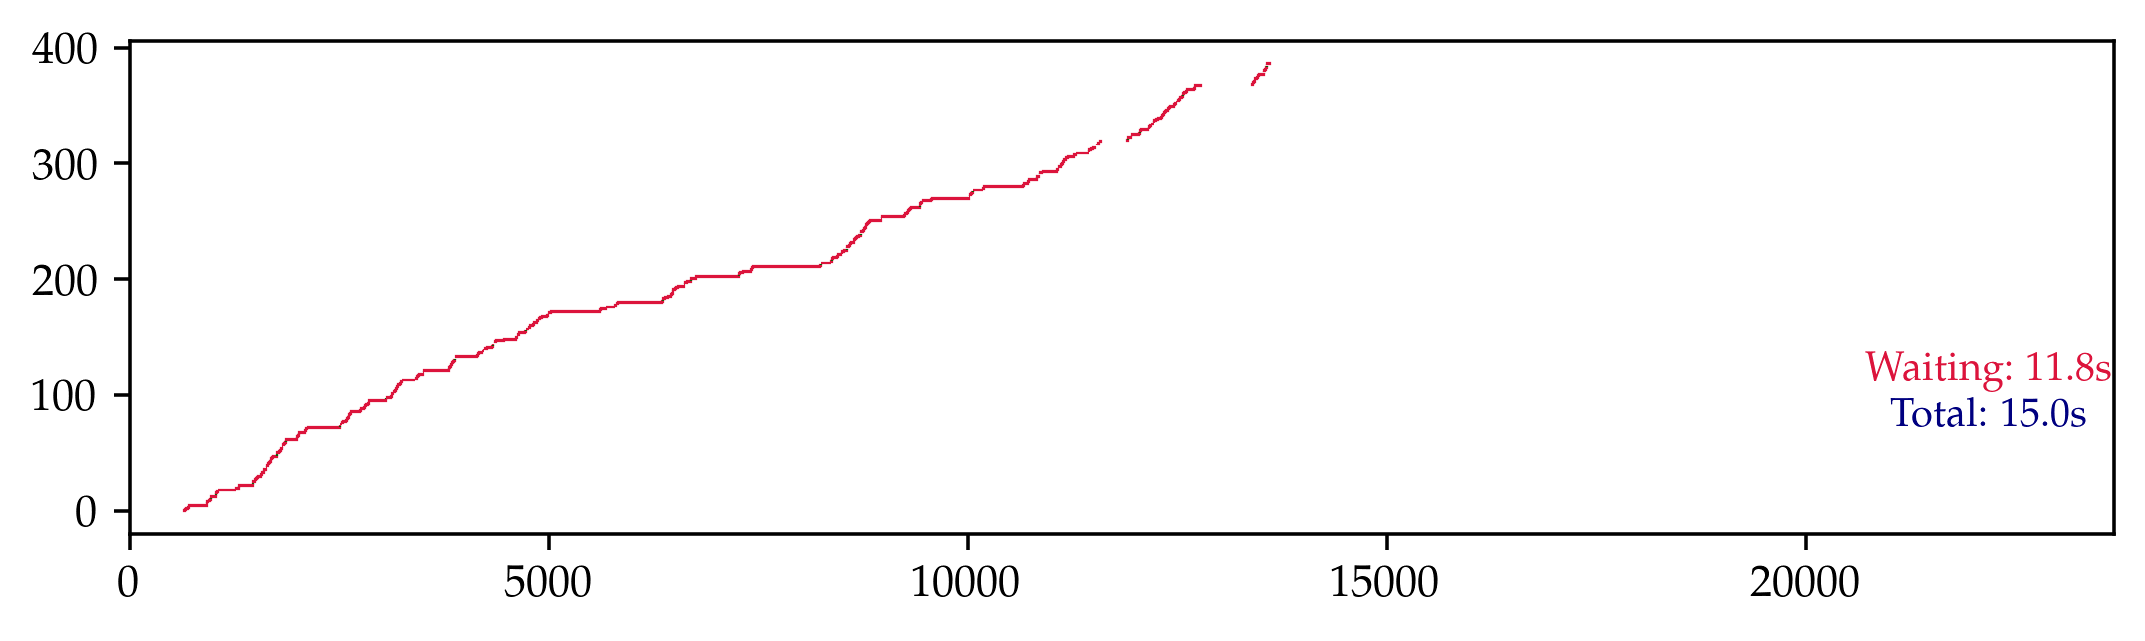

Waiting: 18.72
Execution: 3.25
Total: 21.96


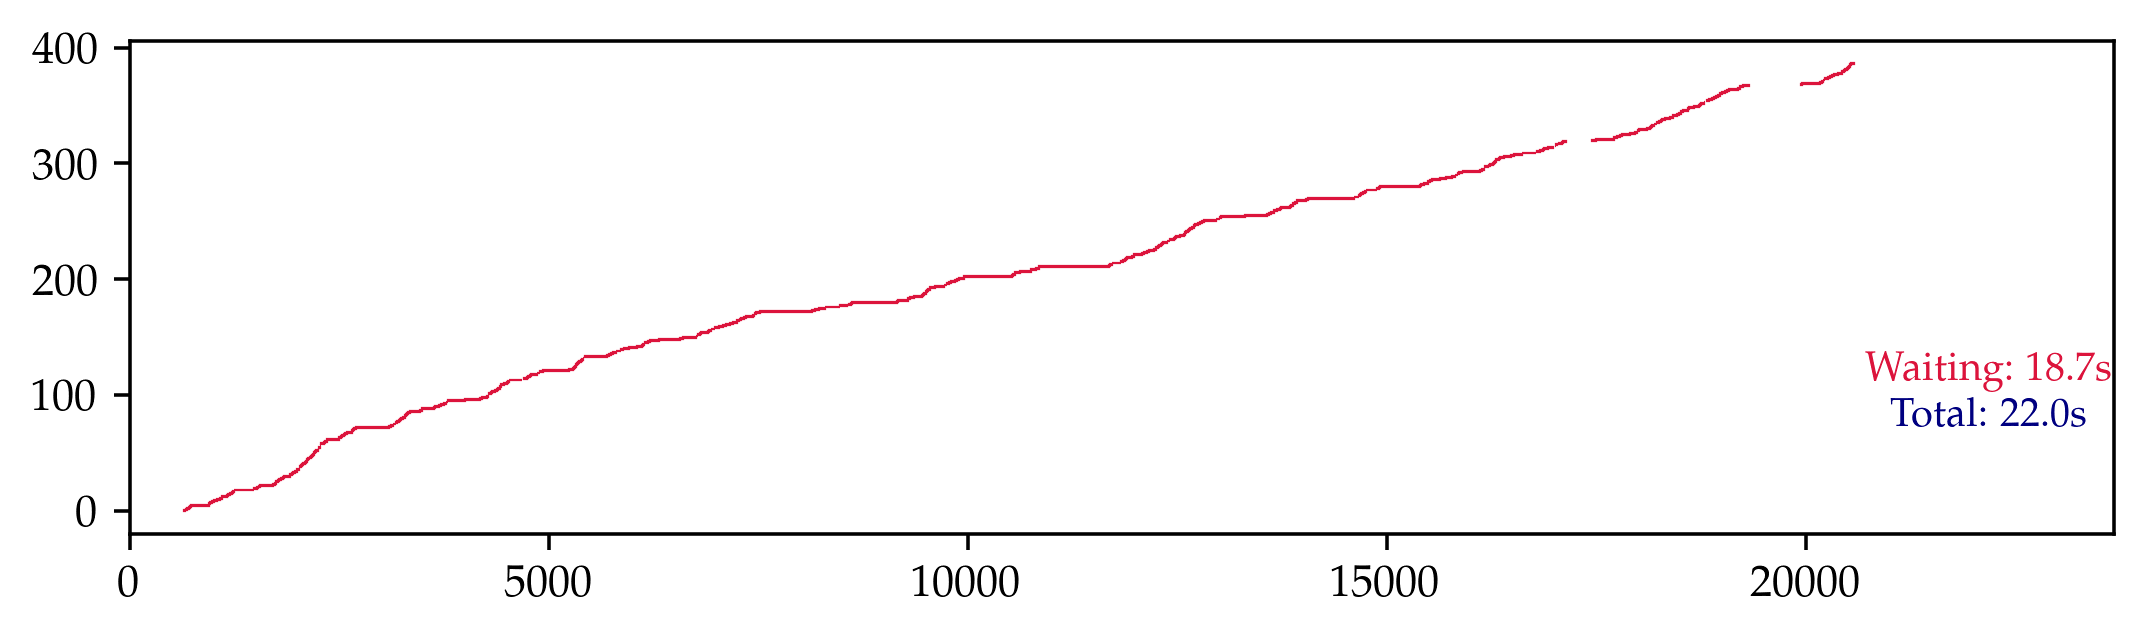

Waiting: 2.32
Execution: 3.08
Total: 5.40


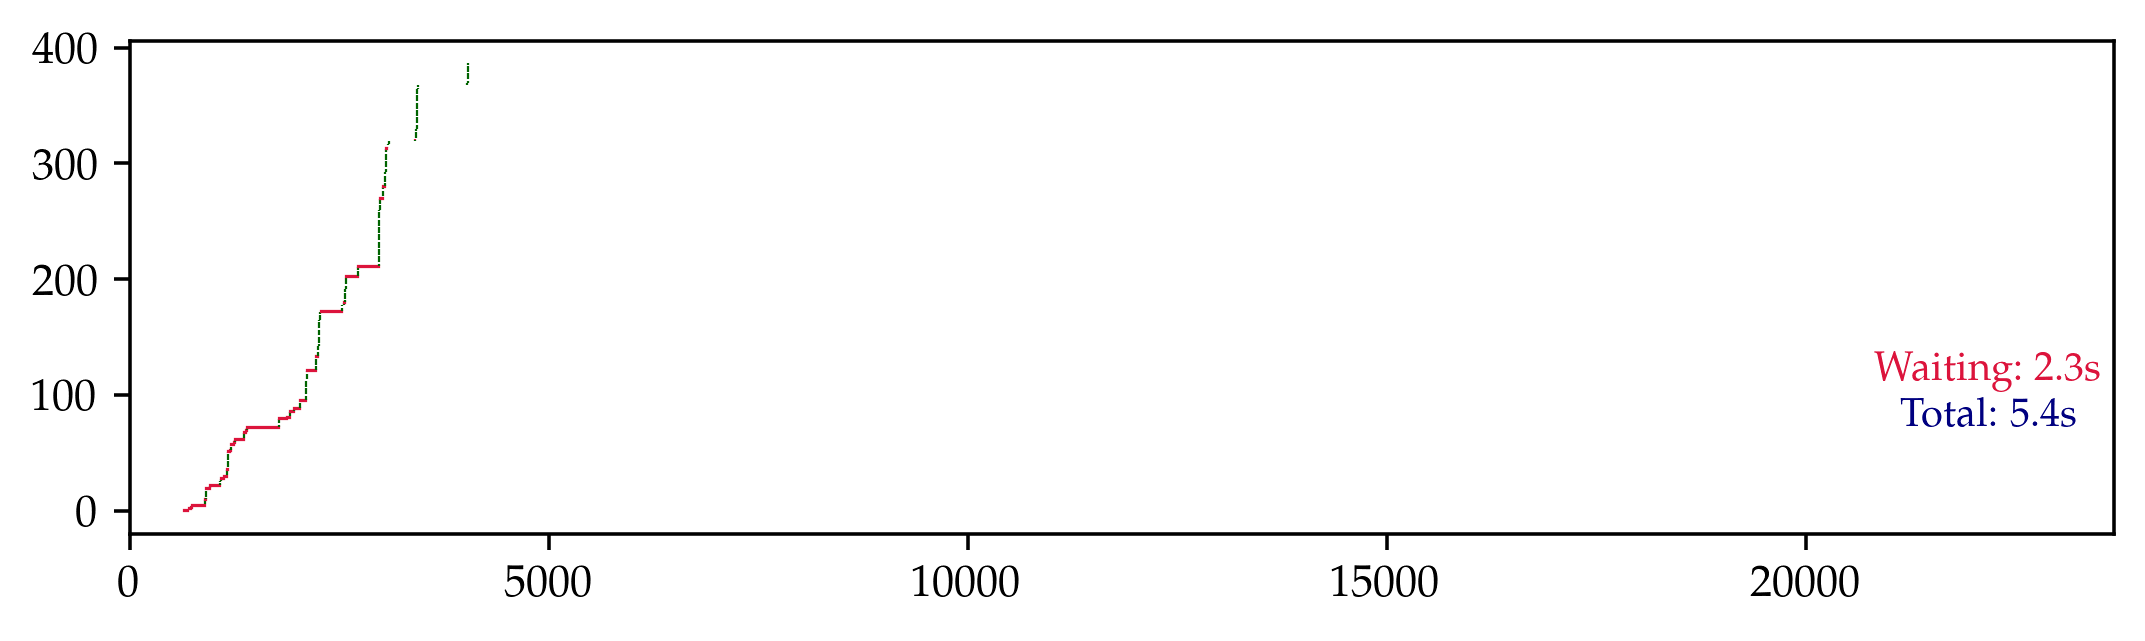

In [46]:
plot('in/tmp.json')